In [1]:
!pip install -q "trl==0.29.1" peft
!pip uninstall -y -q torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 18.7 MB/s eta 0:00:00


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

!rm -rf llm_pii_anonymizer_fr
!git clone https://github.com/ellakonan41/llm_pii_anonymizer_fr.git
import sys
sys.path.append("llm_pii_anonymizer_fr")

from src.prompt import exemple_sft
from src.generation import anonymiser
from src.evaluation import evaluer

import trl, peft, transformers
print("trl", trl.__version__, "| peft", peft.__version__, "| transformers", transformers.__version__)

Cloning into 'llm_pii_anonymizer_fr'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 58 (delta 28), reused 46 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 53.58 KiB | 13.40 MiB/s, done.
Resolving deltas: 100% (28/28), done.
trl 0.29.1 | peft 0.19.1 | transformers 5.0.0


## 3)charger les données

In [3]:
import glob, json

def lire(nom):
    chemin = glob.glob(f"/kaggle/input/**/{nom}", recursive=True)[0]
    with open(chemin, encoding="utf-8") as f:
        return [json.loads(ligne) for ligne in f]

test = lire("test.jsonl")
train_v1 = lire("train_v1.jsonl")
resultats_v0 = json.load(open(glob.glob("/kaggle/input/**/resultats_v0.json", recursive=True)[0]))
print(len(test), len(train_v1))

500 5000


## 4)mettre les données au format d'entraînement

In [4]:
from datasets import Dataset

ds = Dataset.from_list([exemple_sft(ex) for ex in train_v1])
ds = ds.train_test_split(test_size=200, seed=42)
train_ds, eval_ds = ds["train"], ds["test"]

print(train_ds)
print(eval_ds)
print(train_ds[0])

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 4800
})
Dataset({
    features: ['prompt', 'completion'],
    num_rows: 200
})
{'prompt': [{'role': 'system', 'content': "Tu es un outil d'anonymisation de textes. Réécris le texte fourni en remplaçant chaque donnée personnelle par son type entre crochets, choisi parmi : [GIVENNAME], [SURNAME], [TELEPHONENUM], [CITY], [TIME], [EMAIL], [DATE], [STREET], [BUILDINGNUM], [IDCARDNUM], [TITLE], [AGE], [ZIPCODE], [PASSPORTNUM], [SEX], [TAXNUM], [SOCIALNUM], [CREDITCARDNUMBER], [DRIVERLICENSENUM], [GENDER]. Ne modifie rien d'autre dans le texte. Réponds uniquement avec le texte anonymisé."}, {'role': 'user', 'content': "Gülden Lizandra répond: Super ! J'aimerais beaucoup les voir. Mon adresse email est V@yahoo.com."}], 'completion': [{'role': 'assistant', 'content': "[GIVENNAME] répond: Super ! J'aimerais beaucoup les voir. Mon adresse email est [EMAIL]."}]}


## 5)voir un exemple complet et vérifier les longueurs

In [5]:
from transformers import AutoTokenizer

NOM_MODELE = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(NOM_MODELE)

ex = train_ds[0]
texte_complet = tokenizer.apply_chat_template(ex["prompt"] + ex["completion"], tokenize=False)
print(texte_complet)

longueurs = sorted(
    len(tokenizer(tokenizer.apply_chat_template(e["prompt"] + e["completion"], tokenize=False))["input_ids"])
    for e in train_ds
)
print("Longueur médiane :", longueurs[len(longueurs) // 2], "tokens")
print("Longueur max     :", longueurs[-1], "tokens")
print("Au-delà de 512   :", sum(l > 512 for l in longueurs))

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

<|im_start|>system
Tu es un outil d'anonymisation de textes. Réécris le texte fourni en remplaçant chaque donnée personnelle par son type entre crochets, choisi parmi : [GIVENNAME], [SURNAME], [TELEPHONENUM], [CITY], [TIME], [EMAIL], [DATE], [STREET], [BUILDINGNUM], [IDCARDNUM], [TITLE], [AGE], [ZIPCODE], [PASSPORTNUM], [SEX], [TAXNUM], [SOCIALNUM], [CREDITCARDNUMBER], [DRIVERLICENSENUM], [GENDER]. Ne modifie rien d'autre dans le texte. Réponds uniquement avec le texte anonymisé.<|im_end|>
<|im_start|>user
Gülden Lizandra répond: Super ! J'aimerais beaucoup les voir. Mon adresse email est V@yahoo.com.<|im_end|>
<|im_start|>assistant
[GIVENNAME] répond: Super ! J'aimerais beaucoup les voir. Mon adresse email est [EMAIL].<|im_end|>

Longueur médiane : 239 tokens
Longueur max     : 555 tokens
Au-delà de 512   : 2


### 6)configurer LoRA

In [6]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)

## 7)configurer l'entraînement

In [7]:
from trl import SFTConfig

config = SFTConfig(
    output_dir="/kaggle/working/sft_v1",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=15,
    max_length=512,
    fp16=True,
    bf16=False,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    per_device_eval_batch_size=16,
    save_strategy="no",
    report_to="none",
    seed=42,
)

## 8)créer le trainer

In [8]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=NOM_MODELE,
    args=config,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    peft_config=lora_config,
)
trainer.model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Tokenizing train dataset:   0%|          | 0/4800 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/4800 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


## 9)vérifier le masquage de la loss

In [9]:
batch = next(iter(trainer.get_train_dataloader()))
ids = batch["input_ids"][0]
labels = batch["labels"][0]

print("=== TOUT CE QUE LE MODÈLE LIT ===")
print(tokenizer.decode(ids[ids != tokenizer.pad_token_id]))
print("\n=== CE SUR QUOI LA LOSS EST CALCULÉE ===")
print(tokenizer.decode(ids[labels != -100]))

=== TOUT CE QUE LE MODÈLE LIT ===
<|im_start|>system
Tu es un outil d'anonymisation de textes. Réécris le texte fourni en remplaçant chaque donnée personnelle par son type entre crochets, choisi parmi : [GIVENNAME], [SURNAME], [TELEPHONENUM], [CITY], [TIME], [EMAIL], [DATE], [STREET], [BUILDINGNUM], [IDCARDNUM], [TITLE], [AGE], [ZIPCODE], [PASSPORTNUM], [SEX], [TAXNUM], [SOCIALNUM], [CREDITCARDNUMBER], [DRIVERLICENSENUM], [GENDER]. Ne modifie rien d'autre dans le texte. Réponds uniquement avec le texte anonymisé.<|im_end|>
<|im_start|>user
76720 : De rien, c'est tout naturel. Je suis heureux de pouvoir t'aider.<|im_end|>
<|im_start|>assistant
[ZIPCODE] : De rien, c'est tout naturel. Je suis heureux de pouvoir t'aider.<|im_end|>


=== CE SUR QUOI LA LOSS EST CALCULÉE ===
[ZIPCODE] : De rien, c'est tout naturel. Je suis heureux de pouvoir t'aider.<|im_end|>



## 10) Entrainement

In [10]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
50,0.044269,0.048439
100,0.036597,0.038784
150,0.029131,0.022805
200,0.025709,0.018753
250,0.022881,0.015993
300,0.022194,0.015524


TrainOutput(global_step=300, training_loss=0.04763188123703003, metrics={'train_runtime': 631.6004, 'train_samples_per_second': 7.6, 'train_steps_per_second': 0.475, 'total_flos': 2981522704373760.0, 'train_loss': 0.04763188123703003})

## 11)tracer les courbes de loss

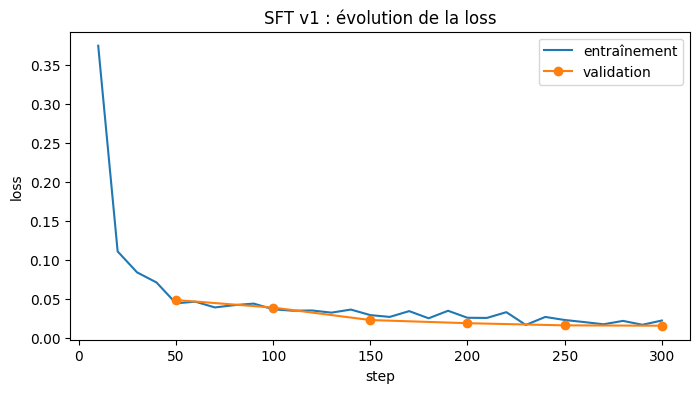

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

historique = pd.DataFrame(trainer.state.log_history)
loss_train = historique.dropna(subset=["loss"])
loss_eval = historique.dropna(subset=["eval_loss"])

plt.figure(figsize=(8, 4))
plt.plot(loss_train["step"], loss_train["loss"], label="entraînement")
plt.plot(loss_eval["step"], loss_eval["eval_loss"], marker="o", label="validation")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("SFT v1 : évolution de la loss")
plt.legend()
plt.savefig("/kaggle/working/loss_v1.png", dpi=120, bbox_inches="tight")
plt.show()

## 12) sauvegarder l'adaptateur

In [12]:
trainer.save_model("/kaggle/working/lora_v1")
!ls -lh /kaggle/working/lora_v1

total 45M
-rw-r--r-- 1 root root 1.1K Oct  1 02:22 adapter_config.json
-rw-r--r-- 1 root root  34M Oct  1 02:22 adapter_model.safetensors
-rw-r--r-- 1 root root 2.5K Oct  1 02:22 chat_template.jinja
-rw-r--r-- 1 root root 5.1K Oct  1 02:22 README.md
-rw-r--r-- 1 root root  665 Oct  1 02:22 tokenizer_config.json
-rw-r--r-- 1 root root  11M Oct  1 02:22 tokenizer.json
-rw-r--r-- 1 root root 5.5K Oct  1 02:22 training_args.bin


## 13) préparer le modèle pour la génération

In [13]:
import torch

model = trainer.model.merge_and_unload().to(torch.float16)
model.gradient_checkpointing_disable()
model.config.use_cache = True
model.eval()

tok_gen = AutoTokenizer.from_pretrained(NOM_MODELE)
tok_gen.padding_side = "left"

## 14) les 3 mêmes textes qu'en v0

In [14]:
essai = anonymiser(model, tok_gen, [ex["source_text"] for ex in test[:3]])
for ex, sortie in zip(test[:3], essai):
    print("ORIGINAL :", ex["source_text"])
    print("ATTENDU  :", ex["masked_text"])
    print("MODÈLE   :", sortie)
    print("-" * 80)

  0%|          | 0/1 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


ORIGINAL : 18:26:13 Ilya Selhida: 'Bien sûr, Metihe Rebeca ! Je suis Tshibola Rolider et je suis impatient de voir le résultat final de notre projet de carte.'
ATTENDU  : [TIME] [GIVENNAME]: 'Bien sûr, [GIVENNAME] ! Je suis [GIVENNAME] [SURNAME] et je suis impatient de voir le résultat final de notre projet de carte.'
MODÈLE   : [TIME] [GIVENNAME]: 'Bien sûr, [GIVENNAME] ! Je suis [GIVENNAME] et je suis impatient de voir le résultat final de notre projet de carte.'
--------------------------------------------------------------------------------
ORIGINAL : Bonjour, je suis Sherap Iblikci et j'aimerais commander un puzzle qui correspond à mes goûts personnels.
ATTENDU  : Bonjour, je suis [GIVENNAME] [SURNAME] et j'aimerais commander un puzzle qui correspond à mes goûts personnels.
MODÈLE   : Bonjour, je suis [GIVENNAME] [SURNAME] et j'aimerais commander un puzzle qui correspond à mes goûts personnels.
--------------------------------------------------------------------------------
ORIGIN

## 15)évaluation complète et comparaison avec la v0

In [15]:
import re

sorties_v1 = anonymiser(model, tok_gen, [ex["source_text"] for ex in test])
resultats_v1 = evaluer(test, sorties_v1)

print(f"{'métrique':<25} {'v0':>8} {'v1':>8}")
for cle in ["protection", "textes_sans_fuite", "preservation", "correspondance_exacte"]:
    print(f"{cle:<25} {resultats_v0[cle]:>8.1%} {resultats_v1[cle]:>8.1%}")

print(f"\n{'type':<20} {'n':>4} {'v0':>8} {'v1':>8}")
for label, n in resultats_v1["effectifs_par_type"].items():
    print(f"{label:<20} {n:>4} {resultats_v0['protection_par_type'].get(label, 0):>8.1%} "
          f"{resultats_v1['protection_par_type'][label]:>8.1%}")

avec_etiquette = sum(bool(re.search(r"\[[A-Z]+\]", s)) for s in sorties_v1)
tres_courts = sum(len(s) < 0.5 * len(ex["source_text"]) for ex, s in zip(test, sorties_v1))
print(f"\nSorties avec au moins une étiquette : {avec_etiquette / len(test):.1%}  (v0 : 14.8%)")
print(f"Sorties 2 fois plus courtes        : {tres_courts / len(test):.1%}  (v0 : 19.6%)")

  0%|          | 0/32 [00:00<?, ?it/s]

métrique                        v0       v1
protection                   42.9%    99.7%
textes_sans_fuite            39.8%    99.4%
preservation                 27.2%    99.7%
correspondance_exacte         0.0%    77.8%

type                    n       v0       v1
GIVENNAME             340    42.1%    99.7%
SURNAME               135    34.1%   100.0%
TELEPHONENUM           91    56.0%   100.0%
CITY                   83    31.3%   100.0%
TIME                   73    50.7%   100.0%
EMAIL                  63    52.4%   100.0%
STREET                 54    24.1%   100.0%
DATE                   53    52.8%   100.0%
BUILDINGNUM            47    38.3%   100.0%
TITLE                  36    50.0%    97.2%
IDCARDNUM              26    57.7%   100.0%
AGE                    25    48.0%    96.0%
ZIPCODE                17    29.4%   100.0%
CREDITCARDNUMBER       12    41.7%   100.0%
PASSPORTNUM            12    75.0%   100.0%
TAXNUM                 10    30.0%   100.0%
DRIVERLICENSENUM       10    70

## 16)sauvegarder

In [16]:
with open("/kaggle/working/sorties_v1.jsonl", "w", encoding="utf-8") as f:
    for ex, sortie in zip(test, sorties_v1):
        f.write(json.dumps({"uid": ex["uid"], "sortie": sortie}, ensure_ascii=False) + "\n")
with open("/kaggle/working/resultats_v1.json", "w", encoding="utf-8") as f:
    json.dump(resultats_v1, f, ensure_ascii=False, indent=2)

## 17)analyser les erreurs restantes

In [17]:
from src.evaluation import evaluer_exemple

print("=== TEXTES AVEC FUITE ===")
for ex, s in zip(test, sorties_v1):
    r = evaluer_exemple(ex, s)
    if r["nb_protegees"] < r["nb_entites"]:
        print("ORIGINAL :", ex["source_text"])
        print("ATTENDU  :", ex["masked_text"])
        print("MODÈLE   :", s)
        print("-" * 80)

print("\n=== 5 TEXTES SANS FUITE MAIS NON IDENTIQUES À LA RÉFÉRENCE ===")
n = 0
for ex, s in zip(test, sorties_v1):
    r = evaluer_exemple(ex, s)
    if r["nb_protegees"] == r["nb_entites"] and not r["exact"] and n < 5:
        print("ATTENDU :", ex["masked_text"])
        print("MODÈLE  :", s)
        print("-" * 80)
        n += 1

=== TEXTES AVEC FUITE ===
ORIGINAL : Comité d'organisation du festival - Reportage : Le festival folklorique a été un succès, selon le rapport de Wiki Emilce.
ATTENDU  : Comité d'organisation du festival - Reportage : Le festival folklorique a été un succès, selon le rapport de [GIVENNAME].
MODÈLE   : Comité d'organisation du festival - Reportage : Le festival folklorique a été un succès, selon le rapport de Wiki [GIVENNAME].
--------------------------------------------------------------------------------
ORIGINAL : Je suis très intéressé par l'analyse textile et des tissus pour les patches, car je voudrais en apprendre plus sur les méthodes de fabrication utilisées dans les années 27.
ATTENDU  : Je suis très intéressé par l'analyse textile et des tissus pour les patches, car je voudrais en apprendre plus sur les méthodes de fabrication utilisées dans les années [AGE].
MODÈLE   : Je suis très intéressé par l'analyse textile et des tissus pour les patches, car je voudrais en apprendre p